In [241]:
import pandas as pd

import matplotlib.pyplot as plt #provides plotting functions
import seaborn as sns #used for making graph and visualizations

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, log_loss, confusion_matrix, auc

In [177]:
df = pd.read_csv("diabetes.csv")

In [178]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [179]:
df.shape #768 Examples, 9 Features

(768, 9)

In [180]:
df.dtypes.value_counts() #Checking Data Types

int64      5
float64    4
Name: count, dtype: int64

In [181]:
df.isnull().sum() #No Missing Values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**Class Distribution Bar Chart**

In [182]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Text(0.5, 1.0, 'Class Distribution')

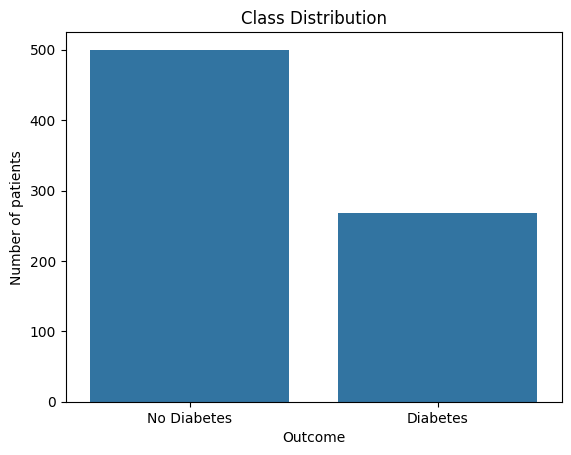

In [183]:
#Creating Class Distribution Bar Chart

#Count how many times each category appears and create bars for those counts.

sns.countplot(x="Outcome", data=df) # X-axis -> Outcome Column
plt.xticks([0, 1], ["No Diabetes", "Diabetes"]) #changes labels 0 and 1 to diabetic and non-diabetic
plt.ylabel("Number of patients")
plt.title("Class Distribution")

Imbalanced DataSet Mostly Non Diabetic Patient's Data

**SPLITTING DATA**

In [184]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

In [185]:
X.shape

(768, 8)

In [186]:
y.shape

(768,)

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [188]:
X_train.shape

(614, 8)

In [189]:
X_test.shape

(154, 8)

In [190]:
model1 = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_leaf=1, random_state=42)

**FULLY-GROWN, DELIBERATELY OVERFIT TREE**

In [191]:
model1.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [192]:
y_pred1_test = model1.predict(X_test)
y_pred1_train = model1.predict(X_train)

In [193]:
print(f"Training Data: {((accuracy_score(y_train, y_pred1_train))*100):.2f}%")
print(f"Testing Data: {((accuracy_score(y_test, y_pred1_test))*100):.2f}%")

Training Data: 100.00%
Testing Data: 83.77%


Can clearly see that 100% Accuracy on Training Data means **OverFitting**

**TUNE VIA CROSS-VALIDATION**

In [194]:
param_grid={
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

Using Strafied K Fold as Class is not equally distributed

Stratified K-Fold Cross Validation is a technique used for evaluating a model

StratifiedKFold tries to preserve the same class proportion in every fold.

It makes your model evaluation more reliable and fair.

In [195]:
model2 = DecisionTreeClassifier(random_state=42)

In [196]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #5 Folds, Shuffle the data before splitting

grid = GridSearchCV(model2, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

#scoring is metric used to compare different models, n_jobs=-1 means use all available CPU cores

In [197]:
grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [198]:
grid.best_params_ #Best Hyper Parameters

{'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [199]:
print(f"{grid.best_score_ * 100:.2f}%") #Best Accuracy Score

86.16%


In [200]:
tuned_model = grid.best_estimator_ #Best classifier

In [201]:
y_pred2_test = tuned_model.predict(X_test)
y_pred2_train = tuned_model.predict(X_train)

In [202]:
print(f"Training Data: {((accuracy_score(y_train, y_pred2_train))*100):.2f}%")
print(f"Testing Data: {((accuracy_score(y_test, y_pred2_test))*100):.2f}%")

Training Data: 93.49%
Testing Data: 82.47%


**Test vs Train Accuracy Curve**

In [203]:
depths = range(1, 21)
train_accuracy, test_accuracy = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, min_samples_leaf=1, random_state=42)
    model.fit(X_train, y_train)
    train_accuracy.append(accuracy_score(y_train, model.predict(X_train)))
    test_accuracy.append(accuracy_score(y_test, model.predict(X_test)))

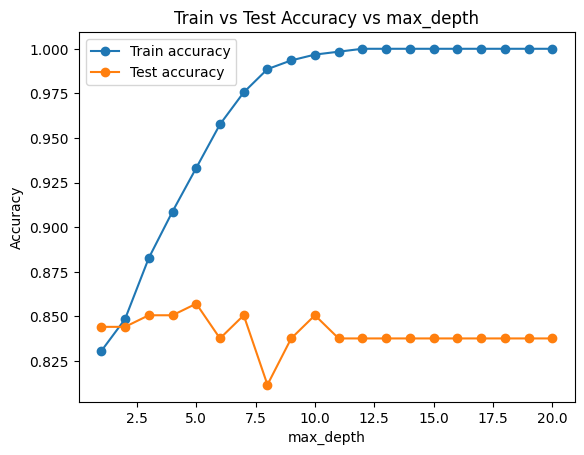

In [204]:
plt.plot(depths, train_accuracy, marker="o", label="Train accuracy")
plt.plot(depths, test_accuracy, marker="o", label="Test accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy vs max_depth")
plt.legend()

In [205]:
import numpy as np

best_depth_by_test = list(depths)[int(np.argmax(test_accuracy))]
print(f"\n[Plot 3] Test accuracy peaks at max_depth={best_depth_by_test} "
      f"(test acc={(max(test_accuracy)*100):.3f}%); train accuracy keeps climbing toward 1.0.")


[Plot 3] Test accuracy peaks at max_depth=5 (test acc=85.714%); train accuracy keeps climbing toward 1.0.


**COST COMPLEXITY PRUNING (CCP_APLHA)**


ccp_alpha controls how aggressively we prune:

ccp_alpha = 0 → no pruning

small ccp_alpha → little pruning

larger ccp_alpha → more pruning

very large ccp_alpha → tree can become extremely small

In [215]:
path = model1.cost_complexity_pruning_path(X_train, y_train) #If I prune you step by step, what ccp_alpha values can I use?

ccp_alphas, impurities = path.ccp_alphas, path.impurities

ccp_alphas = ccp_alphas[:-1]
impurities = impurities[:-1]

#Why remove the last one?
#The largest alpha usually produces a tree with only one node.

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    trees.append(model)

train_accuracy_alpha = [accuracy_score(y_train, t.predict(X_train)) for t in trees]
test_accuracy_alpha = [accuracy_score(y_test, t.predict(X_test)) for t in trees]

n_leaves_alpha = [t.get_n_leaves() for t in trees]

best_alpha_index = int(np.argmax(test_accuracy_alpha))

best_alpha = ccp_alphas[best_alpha_index]

print(f"Best ccp_alpha (max test accuracy): {best_alpha:.5f}")
print(f"Test accuracy at best alpha: {((test_accuracy_alpha[best_alpha_index])*100):.3f}%")
print(f"Leaves at best alpha: {n_leaves_alpha[best_alpha_index]} "
      f"(vs {model1.get_n_leaves()} in the unpruned tree)")

Best ccp_alpha (max test accuracy): 0.00803
Test accuracy at best alpha: 86.364%
Leaves at best alpha: 6 (vs 62 in the unpruned tree)


In [223]:
pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)
y_pred_pruned = pruned_tree.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)*100

**Graph 1:** ccp_alpha vs impurity

**Graph 2:** ccp_alpha vs train/test accuracy

Text(0.5, 0.98, 'Plot 4: Cost-Complexity Pruning Path')

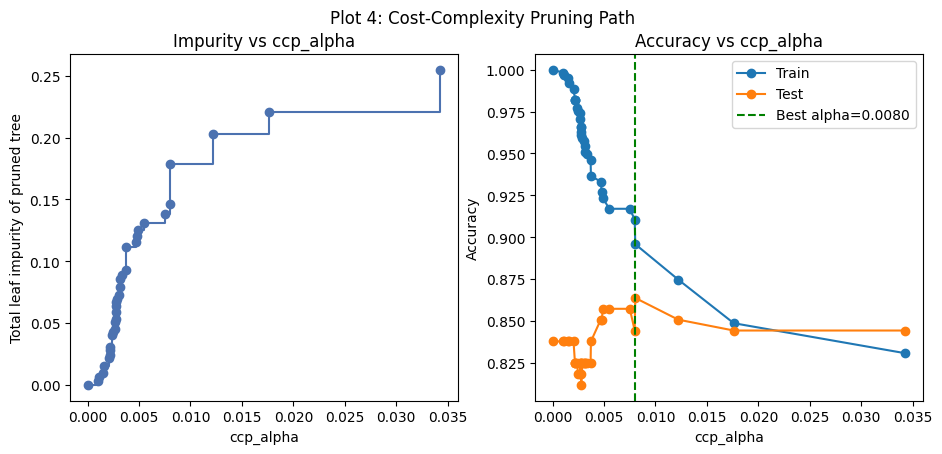

In [224]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

#Graph1

axes[0].plot(
    ccp_alphas,
    impurities,
    marker="o",
    drawstyle="steps-post",
    color="#4C72B0"
)

axes[0].set_xlabel("ccp_alpha")
axes[0].set_ylabel("Total leaf impurity of pruned tree")
axes[0].set_title("Impurity vs ccp_alpha")

#Graph 2

axes[1].plot(ccp_alphas, train_accuracy_alpha, marker="o", label="Train")
axes[1].plot(ccp_alphas, test_accuracy_alpha, marker="o", label="Test")
axes[1].axvline(best_alpha, color="green", linestyle="--", label=f"Best alpha={best_alpha:.4f}")
axes[1].set_xlabel("ccp_alpha")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs ccp_alpha")
axes[1].legend()
plt.suptitle("Plot 4: Cost-Complexity Pruning Path")

**FINAL EVALUATION (pruned tree)**

In [230]:
y_proba = pruned_tree.predict_proba(X_test)[:, 1]

precision_pruned = precision_score(y_test, y_pred_pruned)
recall_pruned = recall_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned)
ll = log_loss(y_test, pruned_tree.predict_proba(X_test)) #Lower log loss is better.

In [231]:
print(f"Accuracy : {accuracy_pruned:.3f}")
print(f"Precision: {precision_pruned:.3f}")
print(f"Recall   : {recall_pruned:.3f}")
print(f"F1       : {f1_pruned:.3f}")
print(f"Log loss : {ll:.3f}")
print(f"Depth: {pruned_tree.get_depth()}, Leaves: {pruned_tree.get_n_leaves()}")

Accuracy : 86.364
Precision: 0.804
Recall   : 0.818
F1       : 0.811
Log loss : 0.808
Depth: 5, Leaves: 6


**Visualized tree (top levels)**

Text(0.5, 1.0, 'Plot 2: Final Pruned Tree (top 3 levels shown)')

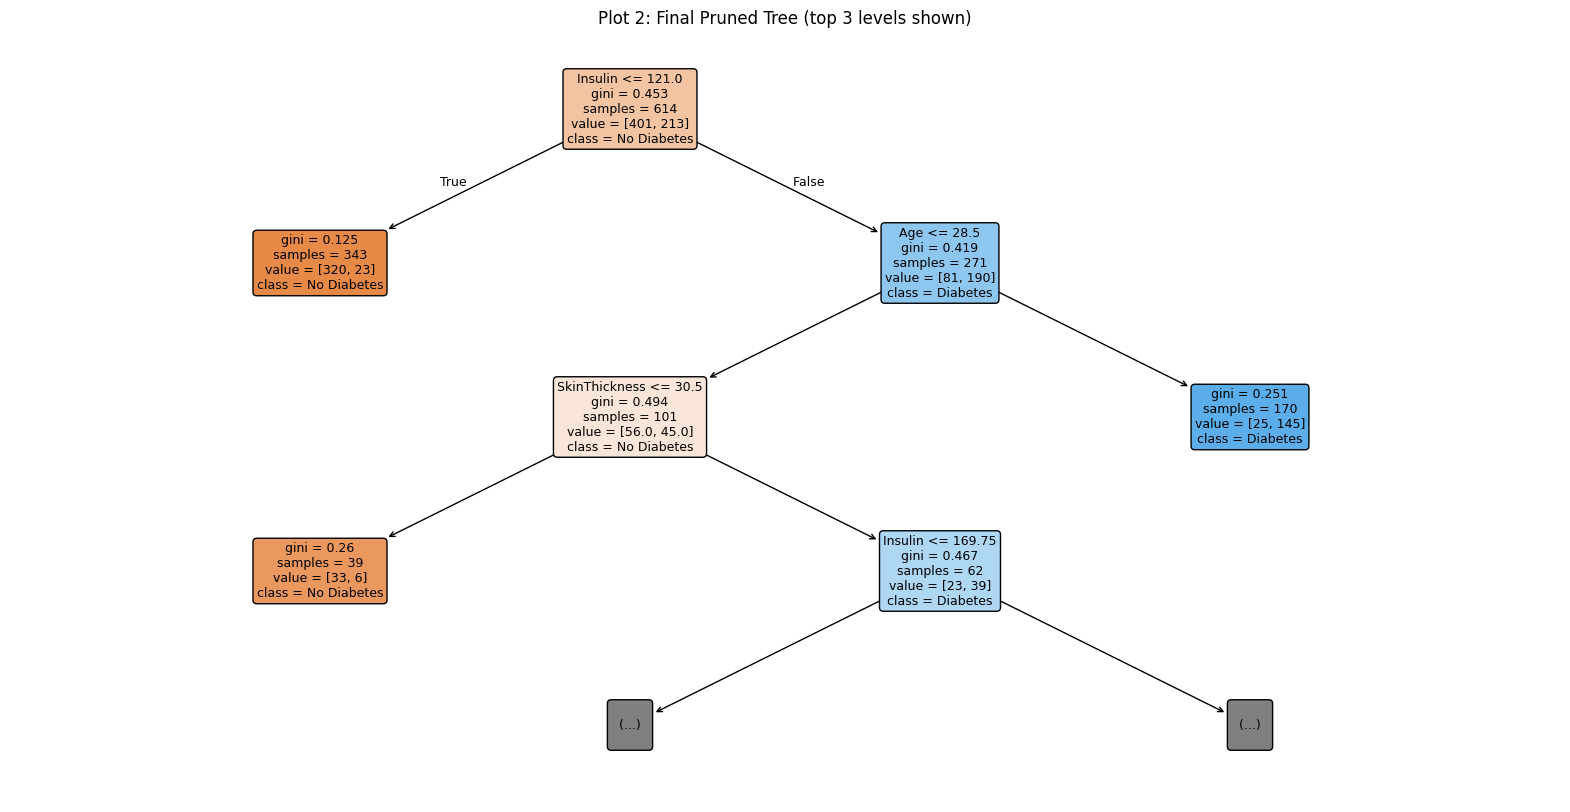

In [235]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    pruned_tree, max_depth=3, feature_names=X.columns, class_names=["No Diabetes", "Diabetes"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Plot 2: Final Pruned Tree (top 3 levels shown)")

**Confusion Matrix**


Confusion matrix breakdown: TN=88, FP=11, FN=10, TP=45


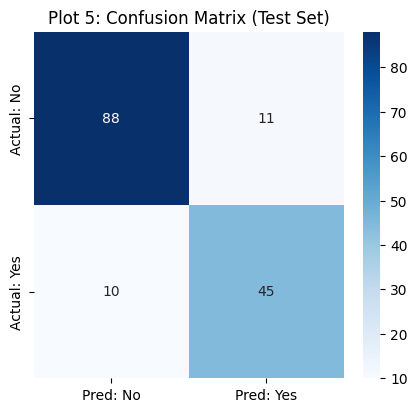

In [237]:
cm = confusion_matrix(y_test, y_pred_pruned)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No", "Pred: Yes"],
            yticklabels=["Actual: No", "Actual: Yes"], ax=ax)
ax.set_title("Plot 5: Confusion Matrix (Test Set)")

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix breakdown: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

**Plot 6: ROC curve**

ROC AUC: 0.882


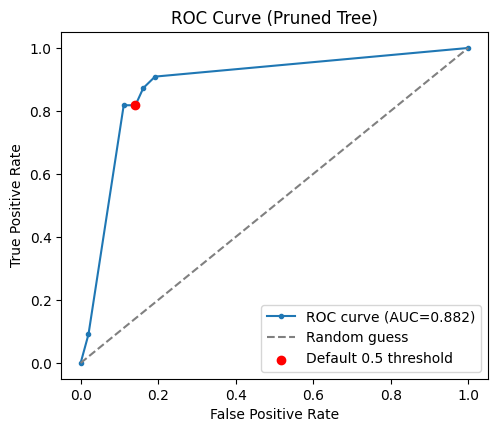

In [247]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr, tpr, marker="o", markersize=3, label=f"ROC curve (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
# mark default 0.5 threshold operating point
default_idx = np.argmin(np.abs(roc_thresholds - 0.5))
ax.scatter(fpr[default_idx], tpr[default_idx], color="red", zorder=5,
           label="Default 0.5 threshold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (Pruned Tree)")
ax.legend()

print(f"ROC AUC: {roc_auc:.3f}")

**Feature Importance**


Feature importances:
 Glucose                     0.811092
SkinThickness               0.124768
DiabetesPedigreeFunction    0.064140
Age                         0.000000
BloodPressure               0.000000
BMI                         0.000000
Insulin                     0.000000
Pregnancies                 0.000000
dtype: float64


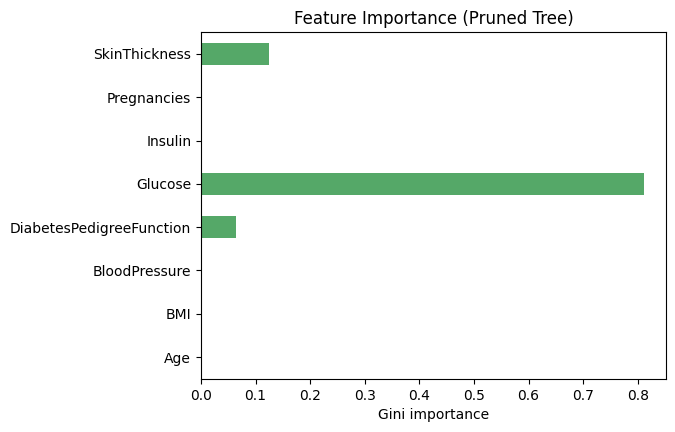

In [248]:
importances = pd.Series(pruned_tree.feature_importances_, index=(X.columns).sort_values(ascending=True))
fig, ax = plt.subplots(figsize=(6, 4.5))
importances.plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("Gini importance")
ax.set_title("Feature Importance (Pruned Tree)")

print("\nFeature importances:\n", importances.sort_values(ascending=False))

**2D decision boundary (Glucose vs BMI, the two most intuitive features)**

Text(0, 0.5, 'BMI')

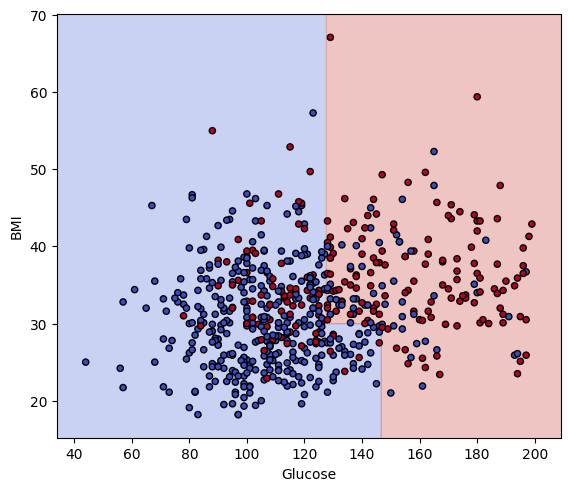

In [258]:
f1_name, f2_name = "Glucose", "BMI"
X2 = X_train[[f1_name, f2_name]].values
y2 = y_train.values
boundary_tree = DecisionTreeClassifier(
    ccp_alpha=best_alpha, random_state=42
)
# refit on just these 2 features so the boundary is meaningful in 2D
boundary_tree.fit(X2, y2)

x_min, x_max = X2[:, 0].min() - 10, X2[:, 0].max() + 10
y_min, y_max = X2[:, 1].min() - 3, X2[:, 1].max() + 3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = boundary_tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="coolwarm", edgecolor="k", s=20)
ax.set_xlabel(f1_name)
ax.set_ylabel(f2_name)

**TRACE ONE MISCLASSIFIED EXAMPLE BY HAND**

In [261]:
mis_idx = np.where(y_pred_pruned != y_test.values)[0]
chosen = mis_idx[0]
sample = X_test.iloc[[chosen]]
true_label = y_test.iloc[chosen]
pred_label = y_pred_pruned[chosen]

print(f"Chosen misclassified test row (index {chosen}):")
print(sample.to_string(index=False))
print(f"True label: {true_label}, Predicted label: {pred_label}")

node_indicator = pruned_tree.decision_path(sample)
leaf_id = pruned_tree.apply(sample)
feature = pruned_tree.tree_.feature
threshold = pruned_tree.tree_.threshold
node_index = node_indicator.indices

trace_lines = []
for node_id in node_index:
    if leaf_id[0] == node_id:
        proportions = pruned_tree.tree_.value[node_id][0]
        n_samples_here = pruned_tree.tree_.n_node_samples[node_id]
        counts = (proportions * n_samples_here).round().astype(int)
        trace_lines.append(
            f"  -> LEAF node {node_id}: {n_samples_here} training samples landed here "
            f"(class 0: {counts[0]}, class 1: {counts[1]}) "
            f"-> majority vote = class {np.argmax(proportions)} "
            f"({proportions[np.argmax(proportions)]*100:.1f}% of this leaf)"
        )
    else:
        f_name = X.columns[feature[node_id]]
        f_val = sample.iloc[0, feature[node_id]]
        thresh = threshold[node_id]
        direction = "<=" if f_val <= thresh else ">"
        trace_lines.append(
            f"  Node {node_id}: is {f_name} ({f_val}) {'<=' if f_val <= thresh else '>'} {thresh:.2f}? "
            f"-> goes {'LEFT' if f_val <= thresh else 'RIGHT'}"
        )
print("\nPath from root to leaf:")
for line in trace_lines:
    print(line)


Chosen misclassified test row (index 0):
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  DiabetesPedigreeFunction  Age
           6       98           58.0             33    190.0 34.0                      0.43   43
True label: 0, Predicted label: 1

Path from root to leaf:
  Node 0: is Insulin (190.0) > 121.00? -> goes RIGHT
  Node 2: is Age (43) > 28.50? -> goes RIGHT
  -> LEAF node 10: 170 training samples landed here (class 0: 25, class 1: 145) -> majority vote = class 1 (85.3% of this leaf)
